# SOLSTICE: Chaco Canyon at dawn, step by step

This notebook walks through how [SOLSTICE](https://brooksgroves.com/solstice/) works, from the terrain to a finished [forge3d](https://github.com/milos-agathon/forge3d) render, using the same code that makes the renders on the page (`tools/render.py`, `tools/layers.py`, `fetch_solstice.py`).

1. The sites and the terrain
2. Where the Sun is on a solstice morning
3. The real skyline, and why it moves sunrise
4. The layer trick that gets 0.5 m lidar past forge3d's mesh cap
5. One render, layer by layer, then finished with sky, labels and caption

Chaco Canyon is the ancestral homeland of the Pueblo peoples and the Diné.

## Setup

**Where it runs.** forge3d draws with Vulkan, so you need a GPU, or Mesa's software renderer (`llvmpipe`) under a virtual display on Linux. Sections 1–4 need no renderer at all. For section 5 on Linux without a GPU:

```bash
sudo apt-get install mesa-vulkan-drivers xvfb
xvfb-run -a jupyter lab        # or: xvfb-run -a jupyter nbconvert --execute --to notebook --inplace notebooks/solstice.ipynb
```

On a locked-down Windows machine, run it on GitHub Actions instead: the **Run notebooks** workflow executes it and commits the outputs.

**Data.** The render data lives on two branches, kept off `main`. From the repo root, `pixi run prep` fetches them into `prep/` (about 0.5 GB).

In [1]:
# Parameters (papermill can override these)
WIDTH = 960          # render width in pixels (16:9); the page uses 1920
SOURCE = "prep"      # "prep": everything from prep/ (no network); "usgs": fetch 1 m 3DEP + 0.6 m NAIP windows
RENDER = True        # False skips section 5 (no GPU / Vulkan needed for the rest)

In [2]:
import json, math, sys, time
from datetime import date, datetime, timedelta
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
import matplotlib.patheffects as pe
from rasterio.warp import transform
from PIL import Image

# find the repo root whether this runs from notebooks/ or the root
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tools" / "render.py").exists())
sys.path[:0] = [str(ROOT / "tools"), str(ROOT)]
PREP, WORK = ROOT / "prep", ROOT / "work"
WORK.mkdir(exist_ok=True)
assert (PREP / "chaco_dem_5m.tif").exists(), "No render data yet: run `pixi run prep` from the repo root"

import forge3d as f3d
import render as R          # tools/render.py
import layers as L          # tools/layers.py
import fetch_solstice as FS # the skyline sunrise math behind data/sky.json

from IPython.display import Image as Show, display
%config InlineBackend.figure_formats = ["jpeg"]
%config InlineBackend.print_figure_kwargs = {"pil_kwargs": {"quality": 85}, "bbox_inches": "tight"}
plt.rcParams.update({"figure.dpi": 100, "font.size": 9})
print("forge3d", f3d.__version__, "| lidar tiles:", len(json.loads((PREP / "lidar/index.json").read_text())["tiles"])
      if (PREP / "lidar/index.json").exists() else "none")

forge3d 1.40.1 | lidar tiles: 89


## 1. The sites and the terrain

The base terrain is a 5 m USGS 3DEP DEM over the whole render extent, with 0.5 m bare-earth ground tiles from the CO_CONMGaps lidar survey patched in around the sites. The colour comes from USGS NAIP aerial photography.

5 m DEM: 4439 x 3906 cells, 22.2 x 19.5 km, 1813-2088 m, EPSG:26913


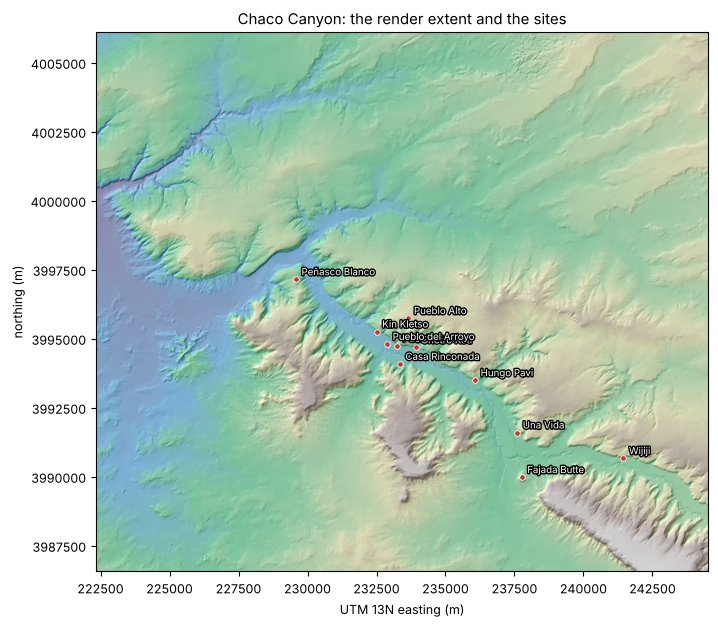

In [3]:
sites = {s["id"]: s for s in json.loads((ROOT / "data/sites.json").read_text())["sites"]}

with rasterio.open(PREP / "chaco_dem_5m.tif") as src:
    k = 4                                            # every 4th cell (20 m) is plenty for a map
    dem = src.read(1, out_shape=(src.height // k, src.width // k))
    b = src.bounds
    crs = src.crs
print(f"5 m DEM: {src.width} x {src.height} cells, {(b.right - b.left) / 1000:.1f} x {(b.top - b.bottom) / 1000:.1f} km, "
      f"{np.nanmin(dem):.0f}-{np.nanmax(dem):.0f} m, {crs}")

shade = LightSource(azdeg=315, altdeg=35).hillshade(np.nan_to_num(dem, nan=np.nanmean(dem)), vert_exag=2, dx=5 * k, dy=5 * k)
ext = (b.left, b.right, b.bottom, b.top)

def site_map(ax):
    ax.imshow(shade, cmap="gray", extent=ext)
    ax.imshow(dem, cmap="terrain", alpha=0.35, extent=ext)
    for s in sites.values():
        (x,), (y,) = transform("EPSG:4326", R.CRS, [s["lon"]], [s["lat"]])
        if ext[0] < x < ext[1] and ext[2] < y < ext[3]:
            ax.plot(x, y, "o", ms=4, color="#c0392b", mec="white", mew=0.6)
            ax.annotate(s["name"], (x, y), xytext=(4, 3), textcoords="offset points", fontsize=7,
                        color="white", path_effects=[pe.withStroke(linewidth=2, foreground="black")])
    ax.ticklabel_format(useOffset=False, style="plain")
    ax.set_xlabel("UTM 13N easting (m)"); ax.set_ylabel("northing (m)")

fig, ax = plt.subplots(figsize=(9, 7))
site_map(ax)
ax.set_title("Chaco Canyon: the render extent and the sites")
plt.show()

## 2. The Sun on a solstice morning

Each still is lit by the real Sun for its date and time. `forge3d.sun_position_utc` gives the azimuth and elevation; the renders use the 2027 solstices, 20 minutes to an hour after sunrise.

solstice date        local      +min  azimuth   elev
summer   2027-06-21  05:54 MDT     0     59.8   -0.9
summer   2027-06-21  06:18 MDT    24     63.3    3.4
summer   2027-06-21  06:54 MDT    60     68.2   10.0
winter   2027-12-21  07:18 MST     0    118.7   -0.9
winter   2027-12-21  07:42 MST    24    122.3    3.3
winter   2027-12-21  08:18 MST    60    128.1    9.2


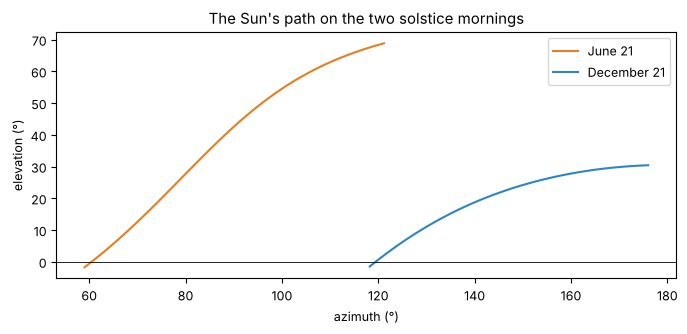

In [4]:
ss, ws = R.solstice_dates(2027)
rows = []
for name, day in (("summer", ss), ("winter", ws)):
    rise = R.sunrise_plus(day, 0, None)              # flat-horizon sunrise at Pueblo Bonito
    for mins in (0, 24, 60):
        t = rise + timedelta(minutes=mins)
        az, el = R.sun_at(t)
        rows.append((name, day.isoformat(), t.strftime("%H:%M %Z"), mins, az, el))
print(f"{'solstice':8} {'date':10}  {'local':9}  {'+min':>4}  {'azimuth':>7}  {'elev':>5}")
for r in rows:
    print(f"{r[0]:8} {r[1]:10}  {r[2]:9}  {r[3]:>4}  {r[4]:7.1f}  {r[5]:5.1f}")

# the morning's arc, both solstices
fig, ax = plt.subplots(figsize=(8, 3.2))
for name, day, c in (("June", ss, "#e67e22"), ("December", ws, "#2e86c1")):
    t0 = datetime(day.year, day.month, day.day, 4, tzinfo=R.TZ)
    ts = [t0 + timedelta(minutes=m) for m in range(0, 8 * 60, 5)]
    ae = np.array([R.sun_at(t) for t in ts])
    up = ae[:, 1] > -2
    ax.plot(ae[up, 0], ae[up, 1], color=c, label=f"{name} {day.day}")
ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("azimuth (°)"); ax.set_ylabel("elevation (°)"); ax.set_title("The Sun's path on the two solstice mornings")
ax.legend(); plt.show()

## 3. The real skyline

A flat-horizon sunrise isn't what anyone standing at Pueblo Bonito sees. `tools/horizon.py` walks outward along every azimuth (0.25° steps) and keeps the highest angle the terrain reaches, with Earth curvature and refraction. It uses the 0.5 m lidar at 1 m from **80 m** to 2.4 km of each site (closer than that, the bare-earth lidar sees the ruin's own rubble mound as a horizon), then the 5 m and 30 m DEMs. The result is `data/horizons.json`.

Sunrise is the moment the Sun's path crosses that line. Here it is for Pueblo Bonito, which sits right under the north cliff.

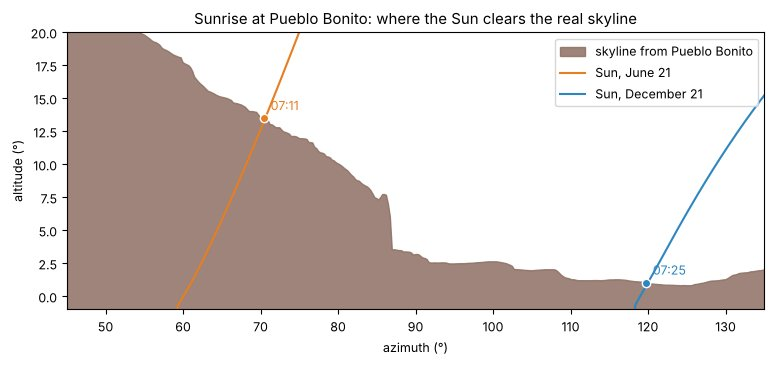

June: flat-horizon sunrise 05:54 at 59.8°; over the skyline 07:11 at 70.4° (skyline 13.5° up), 77 min later
December: flat-horizon sunrise 07:18 at 118.7°; over the skyline 07:25 at 119.7° (skyline 1.0° up), 7 min later


In [5]:
hz = json.loads((ROOT / "data/horizons.json").read_text())
rec = next(s for s in hz["sites"] if s["id"] == "pueblo-bonito")
az = np.arange(len(rec["alt_cdeg"])) * hz["step_deg"]
alt = np.array(rec["alt_cdeg"]) / 100

sky = FS.Skyline(rec, hz["step_deg"])
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.fill_between(az, -2, alt, color="#8d6e63", alpha=0.85, label="skyline from Pueblo Bonito")
results = {}
for name, day, c in (("June", ss, "#e67e22"), ("December", ws, "#2e86c1")):
    o = FS.observer(rec["lat"], rec["lon"], rec["ground_m"] + rec["eye_m"], datetime(day.year, day.month, day.day, tzinfo=FS.TZ))
    t0 = datetime(day.year, day.month, day.day, 4, tzinfo=FS.TZ)
    path = np.array([FS.sun_altaz(o, t0 + timedelta(minutes=m)) for m in range(0, 7 * 60, 2)])  # (alt, az)
    ax.plot(path[:, 1], path[:, 0], color=c, label=f"Sun, {name} {day.day}")
    real = FS.crossing(o, day, sky, True)
    flat = FS.crossing(o, day, None, True)
    results[name] = (flat, real)
    ax.plot(real[1], real[2], "o", color=c, mec="white")
    ax.annotate(f"{real[0]:%H:%M}", (real[1], real[2]), xytext=(5, 6), textcoords="offset points", color=c)
ax.set_xlim(45, 135); ax.set_ylim(-1, 20)
ax.set_xlabel("azimuth (°)"); ax.set_ylabel("altitude (°)"); ax.legend(loc="upper right")
ax.set_title("Sunrise at Pueblo Bonito: where the Sun clears the real skyline")
plt.show()

for name, (flat, real) in results.items():
    lost = (real[0] - flat[0]).total_seconds() / 60
    print(f"{name}: flat-horizon sunrise {flat[0]:%H:%M} at {flat[1]:.1f}°; over the skyline {real[0]:%H:%M} "
          f"at {real[1]:.1f}° (skyline {real[2]:.1f}° up), {lost:.0f} min later")

## 4. The layer trick

forge3d's viewer meshes a terrain at most **2048 vertices across** and point-samples anything bigger to fit. Across the whole ~22 km extent that's about 11 m a vertex, however fine the source is:

In [6]:
span = max(b.right - b.left, b.top - b.bottom)
print(f"extent {span / 1000:.1f} km / {L.MAX_VERTS - 2} vertices = {span / (L.MAX_VERTS - 2):.1f} m per vertex")
for w in (5000.0, 1500.0, 1000.0):
    print(f"  a {w / 1000:g} km wide window fits under the cap at {w / (L.MAX_VERTS - 2):.2f} m")

extent 22.2 km / 2046 vertices = 10.8 m per vertex
  a 5 km wide window fits under the cap at 2.44 m
  a 1.5 km wide window fits under the cap at 0.73 m
  a 1 km wide window fits under the cap at 0.49 m


So each frame is drawn as a stack of layers, each one under the cap, all with the same camera and the same Sun:

- **far**: the whole extent, averaged down to ~11 m (the distant mesas and the horizon)
- **mid** / **near**: just the ground the camera can see within 5 km / 1.5 km, at a few metres to 1 m
- **detail**: for the Pueblo Bonito close-up, the nearest ~450 m at the full 0.5 m

Each window is found by casting rays from the camera into the 5 m DEM (`layers.footprint`), then stretched toward the Sun as far as terrain could actually throw a shadow into it (`layers.shadow_reach`), so the long dawn shadows survive. The close-up of Pueblo Bonito, an hour after the June sunrise, uses tighter tiers than the default (3 km, 1 km and 450 m). Here are its windows:

lidar: 89 tiles at 0.5 m


scene ready in 1s
  mid-nb layer: 1699 x 1355 m at 1 m (texture 2.50 m)


  near-nb layer: 1399 x 1054 m at 0.75 m (texture 2.50 m)


  detail-nb layer: 926 x 698 m at 0.5 m (texture 2.50 m)



June 21, 06:54 MDT: Sun at azimuth 68.2°, 10.0° up
  far              22.21 x 19.54 km at 11 m  ->  2019 x 1776 vertices
  mid-nb            1.70 x  1.35 km at 1 m  ->  1699 x 1355 vertices
  near-nb           1.40 x  1.05 km at 0.75 m  ->  1865 x 1406 vertices
  detail-nb         0.93 x  0.70 km at 0.5 m  ->  1853 x 1395 vertices


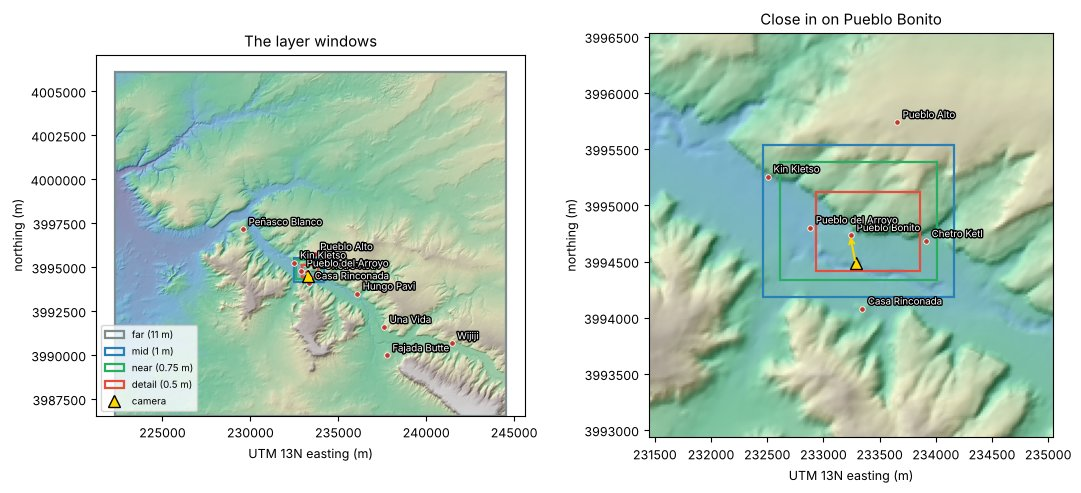

In [7]:
t0 = time.time()
sc = R.Scene(PREP, WORK, SOURCE)                     # builds the lidar-patched 5 m DEM and the far layer (cached in work/)
print(f"scene ready in {time.time() - t0:.0f}s")

# the bonito-close camera, exactly as stills() defines it
px, py = sc.utm(sc.sites["pueblo-bonito"]["lon"], sc.sites["pueblo-bonito"]["lat"])
eye = sc.world(px + 40, py - 250, sc.ground(px, py) + 190)
aim = sc.world(px - 10, py + 10, sc.ground(px, py) + 4)
FOV = 38
SIZE = (WIDTH, WIDTH * 9 // 16)
when = R.sunrise_plus(ss, 60, sc)
sun = R.sun_at(when)
TIERS = (("mid", 3000.0), ("near", 1000.0), ("detail", 450.0))

stack_layers = L.layers_for(sc, [(eye, aim)], FOV, SIZE[0] / SIZE[1], sun, WORK, SOURCE, "-nb", TIERS)
print(f"\n{when:%B %d, %H:%M %Z}: Sun at azimuth {sun[0]:.1f}°, {sun[1]:.1f}° up")
for lay in stack_layers:
    w, h = lay.bounds[2] - lay.bounds[0], lay.bounds[3] - lay.bounds[1]
    print(f"  {lay.name:16} {w / 1000:5.2f} x {h / 1000:5.2f} km at {lay.step:g} m  ->  {w / lay.step:.0f} x {h / lay.step:.0f} vertices")

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
colors = ["#7f8c8d", "#2980b9", "#27ae60", "#e74c3c"]
for ax, zoom in zip(axs, (None, 1800)):
    site_map(ax)
    for lay, c in zip(stack_layers, colors):
        x0, y0, x1, y1 = lay.bounds
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=c, lw=1.6, label=f"{lay.name.split('-')[0]} ({lay.step:g} m)"))
    ex, ey = eye[0], -eye[2]
    ax.plot(ex, ey, "^", color="gold", mec="k", ms=8, label="camera")
    ax.annotate("", xy=(aim[0], -aim[2]), xytext=(ex, ey), arrowprops=dict(arrowstyle="->", color="gold", lw=1.5))
    if zoom:
        ax.set_xlim(px - zoom, px + zoom); ax.set_ylim(py - zoom, py + zoom)
axs[0].legend(loc="lower left", fontsize=7)
axs[0].set_title("The layer windows"); axs[1].set_title("Close in on Pueblo Bonito")
plt.tight_layout(); plt.show()

## 5. One render, layer by layer

Now the actual forge3d part. Each layer gets its own viewer (`render.Viewer`): the DEM, the NAIP texture as an overlay, physically based terrain shading with a 4096² shadow map, height-based ambient occlusion and soft sun visibility. All of them get the same Sun and the same camera, and each one is snapshotted off-screen.

This is what `render.stills(... only=["bonito-close"])` does in one call; here it's opened up so you can see each layer before they're combined. On a CPU (Mesa llvmpipe) it takes a couple of minutes; on a GPU, seconds.

4 layers rendered in 110s


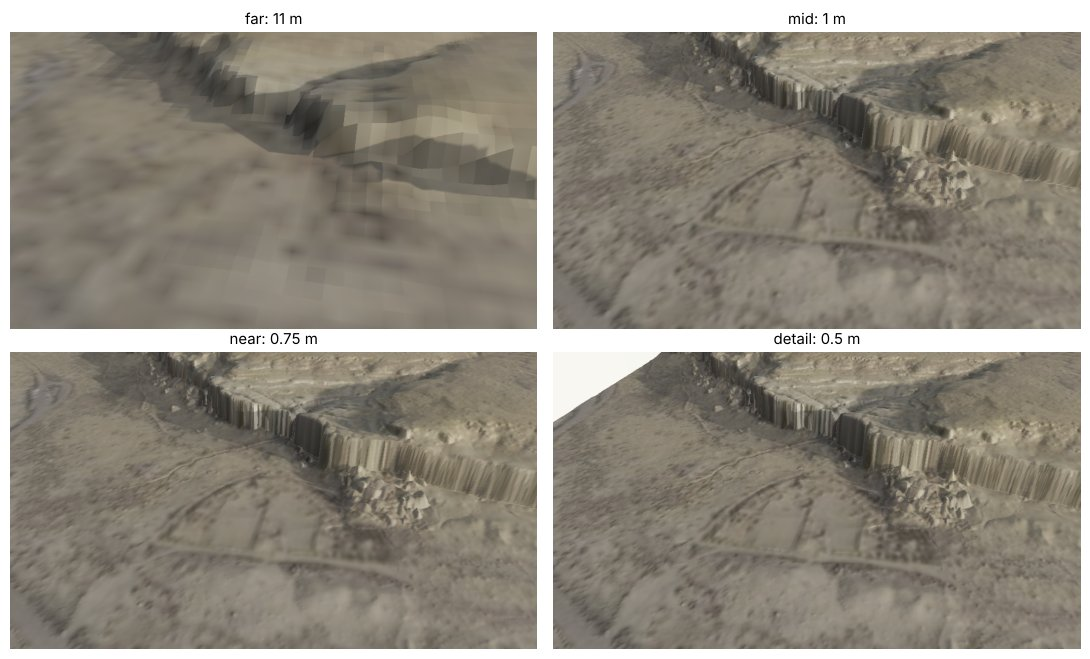

In [8]:
if RENDER:
    out = WORK / "nb"
    out.mkdir(exist_ok=True)
    t0 = time.time()
    stack = R.Stack(sc, stack_layers, SIZE, FOV)
    raws = []
    try:
        stack.sun(*sun)
        for lay, v in zip(stack.layers, stack.vs):
            p = out / f"layer-{lay.name}.png"
            v.shot(eye, aim, FOV, p)
            raws.append(p)
    finally:
        stack.close()
    print(f"{len(raws)} layers rendered in {time.time() - t0:.0f}s")

    fig, axs = plt.subplots(2, 2, figsize=(11, 6.6))
    for ax, p, lay in zip(axs.ravel(), raws, stack_layers):
        ax.imshow(Image.open(p)); ax.set_title(f"{lay.name.split('-')[0]}: {lay.step:g} m"); ax.axis("off")
    plt.tight_layout(); plt.show()

**Compositing.** Coarse to fine, each finer layer replaces the one below wherever it has terrain (`layers.composite`). Beyond a window's edge (the top-left corner of the detail layer above) the viewer shows its plain sky background, which `render.sky_mask` recognises (smooth and pale, where terrain is textured), so the coarser layer shows through there.

**Finishing.** `render.finish` paints a dawn sky gradient into the sky mask, adds haze along the horizon and warms the light. Then the site labels are projected from 3D into the frame with the same camera maths the viewer uses (`render.project`), and the caption goes on.

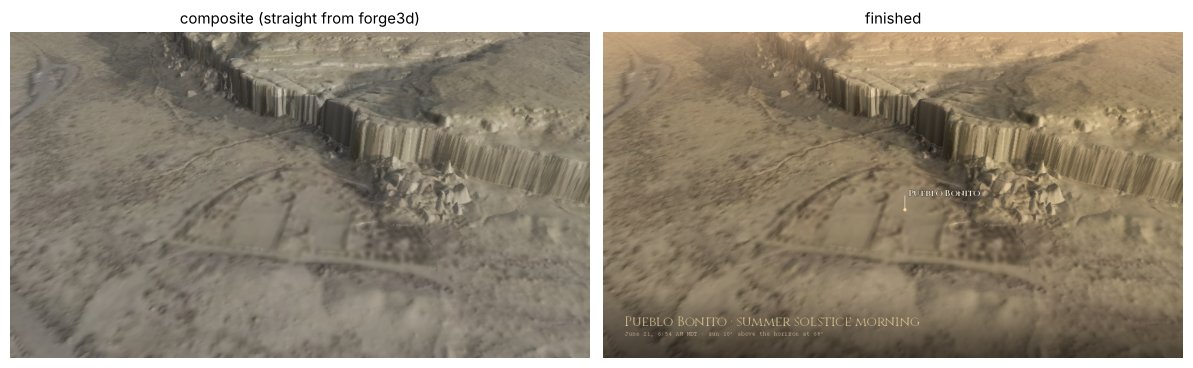

In [9]:
if RENDER:
    comp = L.composite(raws)
    comp_png = out / "composite.png"
    Image.fromarray((np.clip(comp, 0, 1) * 255 + 0.5).astype(np.uint8)).save(comp_png)

    im = R.finish(comp_png, R.DAWN)
    items = []
    for sid in ("pueblo-bonito", "pueblo-del-arroyo", "chetro-ketl"):
        p = R.project(sc.site_world(sid), eye, aim, FOV, SIZE)
        if p and 0 < p[0] < SIZE[0] and 0 < p[1] < SIZE[1]:
            items.append((p[0], p[1], sc.sites[sid]["name"], None, 1.0))
    for x, y, text, sub, a, stem in R.place_labels(items, SIZE):
        R.label(im, (x, y), text, sub, a, stem_px=stem)
    tz = "MDT" if when.dst() else "MST"
    R.caption(im, "Pueblo Bonito · summer solstice morning",
              f"{when:%B} {when.day}, {when:%I:%M %p}".replace(" 0", " ") + f" {tz} · sun {sun[1]:.0f}° above the horizon at {sun[0]:.0f}°")
    final = out / "bonito-close.jpg"
    im.save(final, quality=90)

    fig, axs = plt.subplots(1, 2, figsize=(12, 3.6))
    axs[0].imshow(Image.open(comp_png)); axs[0].set_title("composite (straight from forge3d)")
    axs[1].imshow(im); axs[1].set_title("finished")
    for ax in axs: ax.axis("off")
    plt.tight_layout(); plt.show()

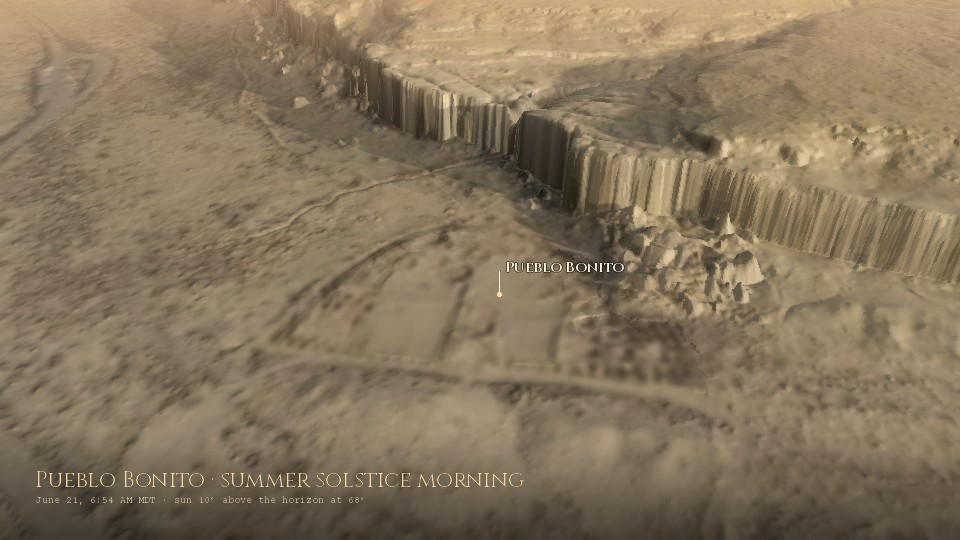

In [10]:
if RENDER:
    display(Show(filename=str(final)))

With `SOURCE = "prep"` the colour comes from the 2.5 m NAIP mosaic, so it's softer than the page. On GitHub Actions the renders use `SOURCE = "usgs"`, which fetches each window's 1 m 3DEP DEM and 0.6 m NAIP on the fly.

## Where to go next

- **The other stills**: `python tools/render.py stills --prep prep --source prep --width 960` renders all four (summer and winter dawn over Fajada Butte, Pueblo Bonito at dawn, and this close-up).
- **The flyover**: 55 seconds at 30 fps along a Catmull-Rom path through eleven keyframes, rendered in 30 parallel chunks on GitHub Actions (**Render with forge3d**). Each chunk builds one layer stack sized to the stretch of the flight it covers.
- **Today's sunrise**: `python fetch_solstice.py` rebuilds `data/sky.json` for today against the skylines, which is what the page reads.

Data: USGS 3DEP (CO_CONMGaps_D24 lidar, 5 m and 30 m DEMs) and USGS NAIP via Microsoft Planetary Computer. Rendering: [forge3d](https://github.com/milos-agathon/forge3d) by Milos Popovic.